In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
from sklearn.datasets import fetch_openml

# Fetch the dataset
# https://www.openml.org/search?type=data&sort=runs&status=active&id=1461
bank_mkt = fetch_openml(data_id=1461, as_frame=True)

# Extract features and target
X = bank_mkt.data
y = bank_mkt.target

# Display the first few rows of the dataset
print(X.head())
print(y.head())


   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16  
0  may  261    1   -1    0  unknown  
1  may  151    1   -1    0  unknown  
2  may   76    1   -1    0  unknown  
3  may   92    1   -1    0  unknown  
4  may  198    1   -1    0  unknown  
0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: category
Categories (2, object): ['1', '2']


In [3]:
#Show unique values of all columns

for column in X.columns:
  print(f"Unique values for column '{column}': {X[column].unique()}")
print(f"Unique values for target column: {y.unique()}")


Unique values for column 'V1': [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values for column 'V2': ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', ..., 'services', 'self-employed', 'unemployed', 'housemaid', 'student']
Length: 12
Categories (12, object): ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', ..., 'student',
                          'technician', 'unemployed', 'unknown']
Unique values for column 'V3': ['married', 'single', 'divorced']
Categories (3, object): ['divorced', 'married', 'single']
Unique values for column 'V4': ['tertiary', 'secondary', 'unknown', 'primary']
Categories (4, object): ['primary', 'secondary', 'tertiary', 'unknown']
Unique values for column 'V5': ['no', 'yes']
Categories (2, object): ['no', 'yes']
Unique values for column 'V6':

In [6]:
# prompt: Prompt: Convert all attribute to numeric values suitable for kNN

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Convert the target variable to numerical values if needed
y = y.astype(int) # Assuming 'yes' and 'no' are already represented as 0 and 1 or can be mapped to 0 and 1. If not, apply a mapping as shown below.
# Example mapping if needed
# y = y.map({'yes': 1, 'no': 0})
print(y)

0        1
1        1
2        1
3        1
4        1
        ..
45206    2
45207    2
45208    2
45209    1
45210    1
Name: Class, Length: 45211, dtype: int64


In [7]:
X.head()

,V1,V6,V10,V12,V13,V14,V15,V2_blue-collar,V2_entrepreneur,V2_housemaid,...,V11_jul,V11_jun,V11_mar,V11_may,V11_nov,V11_oct,V11_sep,V16_other,V16_success,V16_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [9]:
# prompt: prompt: Convert All logical values to 0 and 1

# Assuming 'yes' and 'no' in the target variable are already represented as 0 and 1
# or have been mapped to 0 and 1 in the preceding code.

# If the target variable 'y' contains boolean values (True/False), convert them to 0 and 1:
y = y.astype(int)
print(y)


0        1
1        1
2        1
3        1
4        1
        ..
45206    2
45207    2
45208    2
45209    1
45210    1
Name: Class, Length: 45211, dtype: int64


In [ ]:
# prompt: Convert All logical values to 0 and 1


In [10]:
X.head()

,V1,V6,V10,V12,V13,V14,V15,V2_blue-collar,V2_entrepreneur,V2_housemaid,...,V11_jul,V11_jun,V11_mar,V11_may,V11_nov,V11_oct,V11_sep,V16_other,V16_success,V16_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [11]:
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [12]:
# Step 2: Normalize features (needed for kNN)
from sklearn.preprocessing import StandardScaler # Import StandardScaler from sklearn.preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Optimal k: 19 with accuracy: 0.897


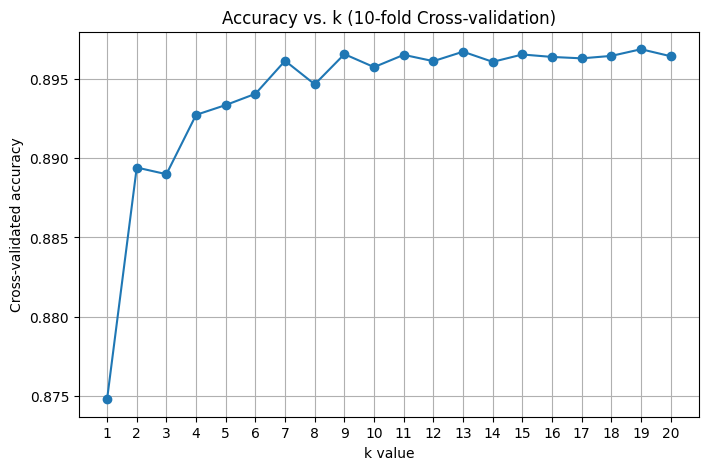

In [13]:
# kNN Classifier with 10-fold cross-validation
from sklearn.model_selection import cross_val_score # Import cross_val_score

k_range = range(1, 21)
scores = []

# 10-fold cross-validation to find optimal k
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=kf, scoring='accuracy').mean()
    scores.append(score)

# Find optimal k
optimal_k = k_range[np.argmax(scores)]
print(f'Optimal k: {optimal_k} with accuracy: {max(scores):.3f}')

# Plot to visualize accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_range, scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Cross-validated accuracy')
plt.title('Accuracy vs. k (10-fold Cross-validation)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [14]:
# Now classify using optimal k
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
y_pred = cross_val_predict(knn_best, X_scaled, y, cv=kf)

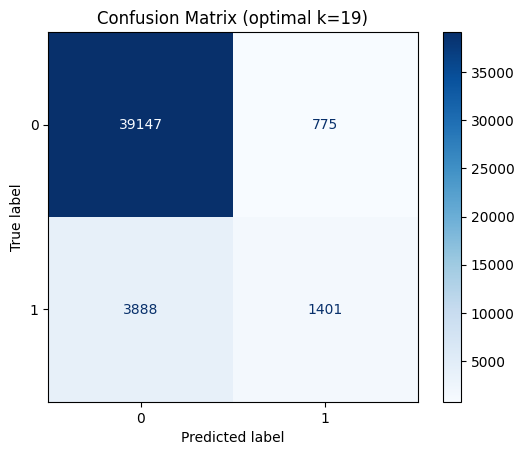

In [15]:
# Confusion Matrix for optimal k
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (optimal k={optimal_k})')
plt.show()

In [16]:
# Classification Report
report = classification_report(y, y_pred, digits=3)
print('Classification Report:\n', report)
#macro avg. is to average the corresponding value with equal weighted.
#weighted avg. is to average with weight of support (no. of datapoint), good for imbalanced data.

Classification Report:
               precision    recall  f1-score   support

           1      0.910     0.981     0.944     39922
           2      0.644     0.265     0.375      5289

    accuracy                          0.897     45211
   macro avg      0.777     0.623     0.660     45211
weighted avg      0.879     0.897     0.877     45211



XGBoost Accuracy: 0.9064469755612076
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7952
           1       0.64      0.50      0.57      1091

    accuracy                           0.91      9043
   macro avg       0.79      0.73      0.76      9043
weighted avg       0.90      0.91      0.90      9043



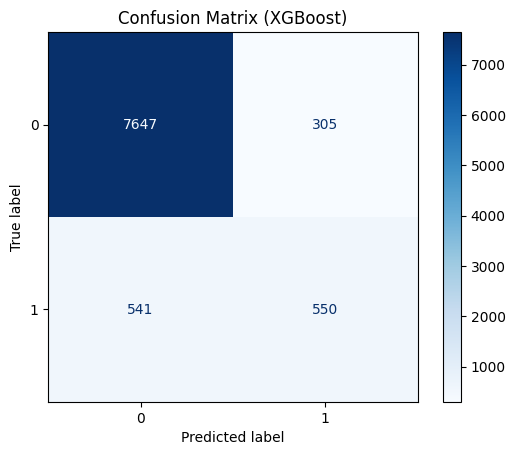

In [18]:
# prompt: prompt: using XGBoost to classify.

# Import necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming X and y are already defined and preprocessed as in the previous code

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert target variable to 0 and 1
# Assuming your target variable has values 1 and 2
y_train = y_train - 1  # Subtract 1 to make values 0 and 1
y_test = y_test - 1    # Subtract 1 to make values 0 and 1


# Initialize and train the XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=42)  # You can tune hyperparameters here
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")

#Further analysis (confusion matrix, classification report, etc.) can be added as needed
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (XGBoost)')
plt.show()